# Day 1: Working towards Machine Learning

In this exercise file, we will go over loading the MNIST data into Numpy arrays, create some basic classifiers using the NearestNeighbor approach, and begin our work with tensor for PyTorch.

## Ex 1: Getting Started with the Data

Begin by running the following two code boxes to load and visualize the data.

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST data
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Explore the data
image, label = train_data[0]
print(f"Number of training images: {len(train_data)}")
print(f"Number of testing images: {len(test_data)}")
print(f"Image shape: {image.shape}")  # [1, 28, 28]
print(f"Label: {label}")  # [1, 28, 28]
print(f"Pixel range: {image.min():.2f} – {image.max():.2f}")


Number of training images: 60000
Number of testing images: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5
Pixel range: 0.00 – 1.00


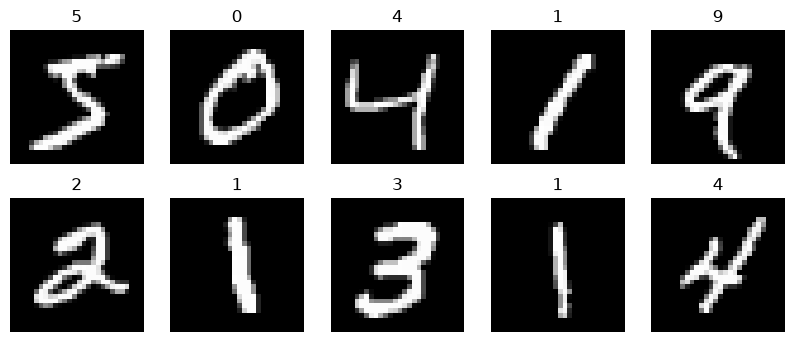

In [2]:
# Visualize a grid of examples
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, lbl = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(lbl))
    ax.axis('off')
plt.show()

In [3]:
test_data[0]


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

## Ex 2: Convert `train_data` to usable Numpy arrays (for now).

Hint: Try using `.data.numpy()` and `.targets.numpy()` to get the images and their respective labels on both the train and test data from above. Also, keep in mind that `y` and `yt` need to be column vectors (n rows, 1 column).

In [4]:
# TODO convert to usable numpy arrays X and y for trian data and Xt and yt for test data
X=train_data.data.numpy()
y=train_data.targets.numpy()
y=y[:, np.newaxis]
Xt=test_data.data.numpy()
yt=test_data.targets.numpy()
yt=yt[:, np.newaxis]
print(X.shape, y.shape, Xt.shape, yt.shape)

(60000, 28, 28) (60000, 1) (10000, 28, 28) (10000, 1)


Flatten the Numpy data arrays (not the label/target ones) so that they only have two dimensions.

Hint: use the `.reshape()` function on these arrays and their `.shape` attribute.

In [5]:
# TODO flatten images so they become only 2D
X = X.reshape(X.shape[0], -1)
Xt = Xt.reshape(Xt.shape[0], -1)
print(X.shape, Xt.shape)

(60000, 784) (10000, 784)


## Ex 3: Distance Metrics: Pixel Distances and Nearest Neighbors!

We will structure the `NearestNeighbor` class as a classifier, with a train and predict method.

Hint #1: For training, we simply need to "remember" all the trianing data.

Hint #2: For predicting, we need to calculate the distance between our testing images stored in our local X and all the training examples, find the index of the type that corresponds with the minimum distance for each one, and return that type. Maybe the function `np.argmin()` can do the index finding for us.

In [6]:
class NearestNeighbor(object):
  def __init__(self):
    
    pass

  def train(self, X, y):
    # TODO training means simply remembering all the training data
    self.X, self.y = X,y

  def predict(self, X):
    # TODO calculate the distance between training points and the X parameter
    dists_sq=np.sum(X**2, axis=1, keepdims=True) + np.sum(self.X**2, axis=1) - 2*X@(self.X.T)
    min_index = np.argmin(dists_sq, axis=1)
    min_indices = min_index
    # TODO finally, choose smallest argument
    return self.y[min_indices]

Now let's create a `NearestNeighbor` classifier using the class we just implemented and use it to make some predictions!

Remember, we stored the training data images and labels in `X` and `y`, while testing images and labels are in `Xt` and `yt`.

In [ ]:
# TODO initialize the NN classifier
nearest_neighbor = NearestNeighbor()


# TODO train the classifier with the training images and labels
nearest_neighbor.train(X, y)

# TODO predict the labels of the test images
yt_predict = nearest_neighbor.predict(Xt)

print('accuracy: %f' % (np.mean(yt_predict == yt)))

## Ex 4: K-Nearest Neighbors

We will structure the `KNearestNeighbor` class similarly to the `NearestNeighbor` above.

Hint #1: For training, we still just "remembering" all the trianing data.

Hint #2: For predicting, we need to calculate the distances, choose the k smallest ones, and return the index of type that occurs the most. The function `np.argmin()` and `np.bincount()` should help us do that.

In [ ]:
class KNearestNeighbor(object):
  def __init__(self, k=5):
    self.k = k

  def train(self, X, y):
    self.X, self.y = X,y
    # TODO training means simply remembering all the training data
    

  def predict(self, X):
    # TODO similarly calculate the distance between triniang points and the X parameter
    dists_sq = np.sum(X**2, axis=1, keepdims=True) + np.sum(self.X**2, axis=1) - 2*X@(self.X.T)

    num_test = dists_sq.shape[0]
    y_pred = np.zeros((num_test, 1), dtype=int)
  
    for i in range(dists_sq.shape[0]):
        # TODO find the k-smallest distances
        
        closest_y = self.y[np.argsort(dists_sq[i])[:self.k]].ravel()
        # predict on the most recurring label of the k-nearest points
        counts = np.bincount(closest_y.astype(int))
        y_pred[i, 0] = np.argmax(counts)
    return y_pred

Now let's create a `KNearestNeighbor` classifier with `k=5` using the class we just implemented and use it to make some predictions!

Remember, we stored the training data images and labels in `X` and `y`, while testing images and labels are in `Xt` and `yt`.

In [ ]:
# TODO initialize the kNN classifier
knn = KNearestNeighbor(k=5)


# TODO train the classifier with the training images and labels
knn.train(X, y)

# TODO predict the labels of the test images
yt_predict = knn.predict(Xt)

print('accuracy: %f' % (np.mean(yt_predict == yt)))

accuracy: 0.113000


## Ex 5: Intro to PyTorch and Tensors

We will now start using PyTorch's array objects made specifically for ML. Why tensors and not just keep the Numpy arrays? Tensors are made especially for GPU acceleration and automatic differentiation (we will talk more about this on Day 2 of ML).

Run this new `torch` library import first.

In [ ]:
import torch

For these tensor arrays, print their shape and the data type they store.

Hint: Same `.shape` attribute should work, and the `.dtype` should do the rest.

In [ ]:
# Tensors are PyTorch's core data structure (like numpy arrays but GPU-capable)
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3, 4)
c = torch.ones(2, 3)
d = torch.randn(3,3)    # random nomalized

# TODO print each tensor array's shape and data type
print("a:", None, None)
print("b:", None, None)
print("c:", None, None)
print("d:", None, None)

Let's try some operations with the following tensors. Feel free to add as many print statements as needed so that the operation make sense.

In [ ]:
# Tensor operations
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

# TODO print the element-wise addition
print(None)

# TODO multiply the two matrices together
print(None)

# TODO print one matrix's transpose
print(None)

# TODO print one matrix's mean and standard deviation
print(None, None)

Let's play with the matrix shapes and dimensions. Why do you think this may be important?

Hint: The `.reshape` should help out work here. Furthermore, `.squeeze` reduce the size-1 dimensions and `.permute` "swaps" dimensions around.

In [ ]:
x = torch.randn(4, 1, 28, 28)   # equivalent to a batch of 4 MNIST images
print("Original shape:", x.shape)       # [batch, channels, H, W]

# TODO shape array x so the new dimensions are [batch, 784]. Remember, 28x28=784.
flat_x = None
print("Flattened:", flat_x.shape)

# TODO drop the size-1 dimensions and print the outcome
non_one_x = None
print("Squeezed:", non_one_x.shape)

# TODO permute x's dimensions so that the new arrays has dimensions [batch, H, W, channels]
perm_x = None
print("Permuted:", perm_x.shape)

Let's explore more of PyTorch's features: automatic gradients (named `autograd`, very smart, right?). We will see why we need gradients on Day 2 of ML (without learning all of Calculus for it, promise).

Autograds are used in Torch for "learning"!

In [ ]:
# The key words here are "requires_grad"
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2 + 2 * x + 1

# Lets see what this did
y.backward()
print("y =", y.item())
print("dy/dx at x=3: ", x.grad.item())

Lastly, let's try an exercise with this gradient feature. We will use this to find the minimum value of $f(x) = (x-5)^2$.

In [ ]:
# Gradient Exercise - finding the minimum of f(x) = (x-5)^2
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1        # learning rate

print(f"{'Step':>4}  {'x':>8}  {'loss':>8}")
print("-" * 26)
for step in range(10):
    loss = (x - 5) ** 2
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()
    print(f"{step+1:>4}  {x.item():>8.4f}  {loss.item():>8.4f}")